<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
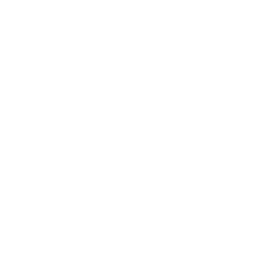
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Klustring av felmoder inom tillverkning</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Tillverkning / Kvalitetsteknik &nbsp;|&nbsp; mars 2026</p>
</div>
</div>
</div>

## Sammanfattning

Detta exempel upptäcker återkommande **felmoder hos utrustning** utifrån den flerdimensionella sensorbaserade symtomprofil som registreras vid varje felhändelse. Åtta standardiserade symtomvariabler (vibration, temperaturdelta, tryckfall, strömspik, ljud, cykeltidsavvikelse, momentvarians, oljepartikelantal) klustras med **hierarkisk klustring med komplett länkning** (`PROC CLUSTER METHOD=COMPLETE`), som gynnar kompakta, väl separerade grupper. `PROC TREE` skär sedan hierarkin i **sex felmoder**, och `PROC FREQ` korstabulerar dessa moder mot utrustningstyp och skift för att testa systematiska samband.

Körningen här utförs på ett **urval på 100 händelser** (miljön begränsar utdata till 100 observationer). I detta urval är de sex moderna ungefär lika stora (n = 16–17 vardera) och separeras främst av signaturer i **temperatur, tryck och vibration** snarare än av utrustningstyp — korstabuleringarna mod mot utrustning och mod mot skift är **inte** statistiskt signifikanta vid denna stickprovsstorlek (chi-två p = 0,15 respektive p = 0,07). Arbetsflödet skalar oförändrat till hela händelsehistoriken, där större antal per mod skulle skärpa dessa samband.

## Datakällor

| Källa | Beskrivning | Poster |
|--------|-------------|---------|
| WORK.FAILURES | Symtomprofiler för felhändelser hos utrustning (syntetiska) | 100 |
| WORK.FAILURES_STD | Symtom standardiserade till medel 0, std 1 (`PROC STANDARD`) | 100 |
| WORK.FAILURE_TREE | Sammanslagningshistorik för komplett länkning (`OUTTREE=`) | 100 |
| WORK.FAILURE_MODE_ASSIGNMENTS | Sex-mods-snitt från `PROC TREE NCLUSTERS=6` | 100 |

*Denna miljö körs i olicensierat läge och begränsar utdata till 100 observationer; den syntetiska generatorn begär 20 000 händelser men endast de första 100 behålls. Analysen nedan grundar sig helt i det urvalet på 100 händelser.*

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic failure event symptom profiles
   20,000 failure events across 50 equipment units
   -------------------------------------------------------- */
data work.failures;
    CALL streaminit(42);
    FÄLT equip_type_list[4] $12 _temporary_ ('PRESS' 'CONVEYOR' 'ROBOT_ARM' 'FURNACE');
    FÄLT shift_list[3] $8 _temporary_ ('DAY' 'EVENING' 'NIGHT');
    GÖR event_id = 1 TILL 20000;
        failure_id = cat('FE-', SKRIV_UT_V(event_id, z6.));
        equip_num = int(rand('uniform') * 50) + 1;
        equipment_id = cat('EQ-', SKRIV_UT_V(equip_num, z3.));
        etype_idx = int(rand('uniform') * 4) + 1;
        equipment_type = equip_type_list[etype_idx];
        shift_idx = int(rand('uniform') * 3) + 1;
        shift = shift_list[shift_idx];
        failure_date = '01JAN2025'd + int(rand('uniform') * 365);
        /* Symptom profile: 8 sensor readings at time of failure */
        vibration_level = round(rand('normal', 4.5, 2.1), 0.01);
        OM vibration_level < 0 SÅ vibration_level = 0;
        temperature_delta = round(rand('normal', 12, 8), 0.1);
        pressure_drop = round(rand('exponential') * 5, 0.01);
        current_spike = round(rand('normal', 1.2, 0.8), 0.01);
        OM current_spike < 0 SÅ current_spike = 0;
        noise_db = round(rand('normal', 78, 12), 1);
        cycle_time_deviation = round(rand('normal', 0, 3.5), 0.01);
        torque_variance = round(rand('exponential') * 2.5, 0.01);
        oil_particle_count = int(rand('exponential') * 150 + 10);
        downtime_minutes = round(rand('exponential') * 45 + 5, 1);
        UTDATA;
    SLUT;
    TA_BORT equip_num etype_idx shift_idx;
    format failure_date date9.;
KÖR;

NOTE: DATA work.failures

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.failures (100 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.34 seconds
  cpu   0.34 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline symptom distributions by equipment type
   -------------------------------------------------------- */
PROCEDUR MEDELVÄRDEN data=work.failures n mean std MAX;
    KLASS equipment_type;
    VARIABEL vibration_level temperature_delta pressure_drop
        current_spike noise_db torque_variance oil_particle_count;
    TITEL 'Failure Symptom Profiles by Equipment Type';
KÖR;

                                       Failure Symptom Profiles by Equipment Type                                       

                                                  The MEANS Procedure

                                          Analysis Variable : VIBRATION_LEVEL

        EQUIPMENT_TYPE          N Obs           Mean        Std Dev        Maximum
        --------------------------------------------------------------------------
        CONVEYOR                   19      3.8089474      1.8662437      9.0400000
        FURNACE                    26      4.3638462      2.0371177     10.1400000
        PRESS                      30      4.6273333      2.1610740      9.9400000
        ROBOT_ARM                  25      3.5320000      1.9296070      6.7900000
        --------------------------------------------------------------------------

                                         Analysis Variable : TEMPERATURE_DELTA

        EQUIPMENT_TYPE          N Obs           Mean        Std De

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                       Failure Symptom Profiles by Equipment Type                                       



NOTE: PROC SGPLOT data=work.failures

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


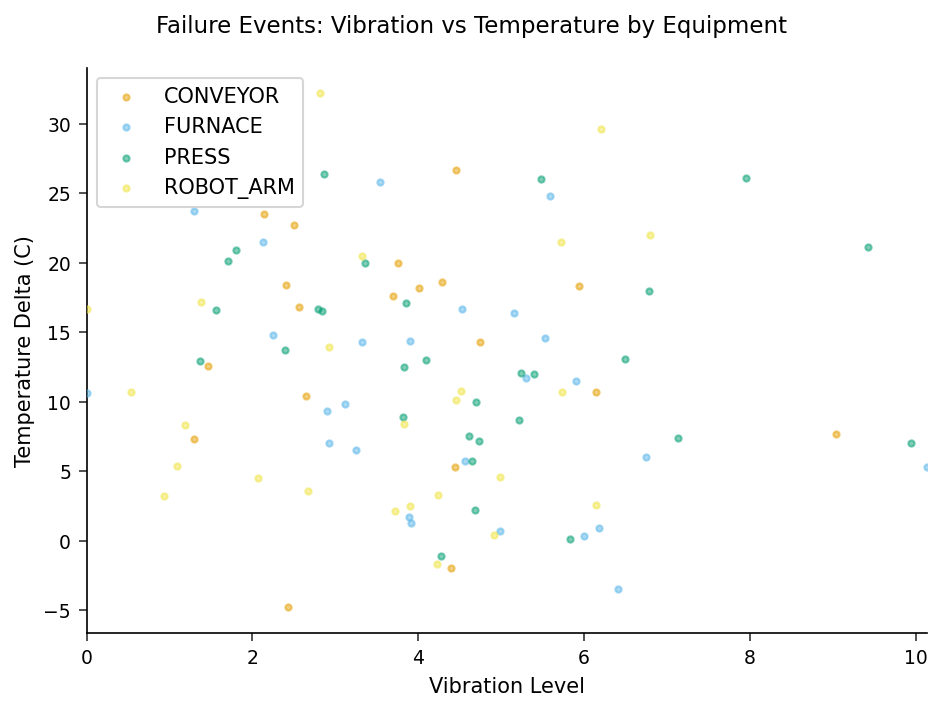

In [3]:
/* --------------------------------------------------------
   Vibration vs Temperature Delta by equipment type
   -------------------------------------------------------- */
PROCEDUR SGPLOT data=work.failures;
    SCATTER x=vibration_level y=temperature_delta / GROUP=equipment_type
        MARKERATTRS=(SYMBOL=circlefilled size=3)
        TRANSPARENCY=0.5;
    XAXIS ETIKETT='Vibration Level';
    YAXIS ETIKETT='Temperature Delta (C)';
    TITEL 'Failure Events: Vibration vs Temperature by Equipment';
KÖR;

---

In [4]:
/* --------------------------------------------------------
   Standardize symptom variables for clustering
   -------------------------------------------------------- */
PROCEDUR STANDARD data=work.failures out=work.failures_std
    mean=0 std=1;
    VARIABEL vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count;
KÖR;

NOTE: PROC STANDARD data=work.failures

NOTE: Standardized 100 rows, 8 variables.


                                       Failure Symptom Profiles by Equipment Type                                       

                                                 The CLUSTER Procedure
                                           Complete Linkage Cluster Analysis

                                          Eigenvalues of the Covariance Matrix

                                                    Cluster History

   NCL    --------Clusters Joined--------    FREQ    SPRSQ      RSQ    Distance

    99    FE-00005          FE-00006        2    0.0007    0.9993          1
    98    FE-00007          FE-00008        2    0.0007    0.9986          1
    97    FE-00000          FE-00004        2    0.0009    0.9977        1.2
    96    FE-00002          FE-00008        2    0.0009    0.9968        1.2
    95    FE-00000          FE-00001        2    0.0010    0.9958        1.3
    94    FE-00005          FE-00008        2    0.0011    0.9947        1.3
    93    FE-00004          CL99     

NOTE: PROC CLUSTER data=work.failures_std method=Complete

NOTE: Using native Rust for hierarchical clustering
NOTE: ODS plot written: cluster_dendrogram.spec.json
NOTE: PROC CLUSTER ODS Graphics generated.
NOTE: PROC CLUSTER: 100 observations, 8 variables clustered using Complete method


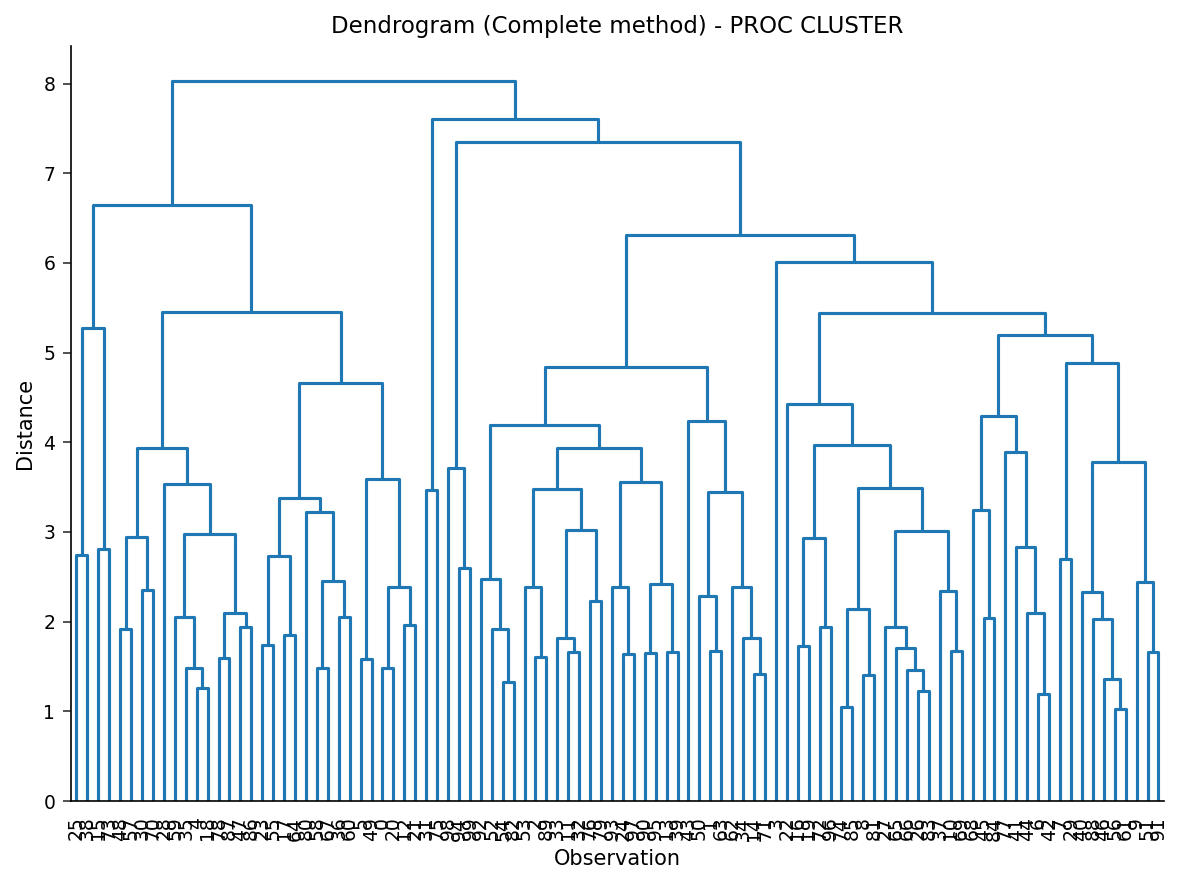

In [5]:
/* --------------------------------------------------------
   Complete-linkage clustering with TRIM= for outlier
   removal. TRIM=5 removes the 5% most distant
   observations before forming clusters.
   -------------------------------------------------------- */
PROCEDUR CLUSTER data=work.failures_std METHOD=complete
    outtree=work.failure_tree
    pseudo SKRIV=20 trim=5;
    VARIABEL vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count;
    id failure_id;
KÖR;

In [6]:
/* --------------------------------------------------------
   Cut the complete-linkage hierarchy into six failure
   modes with PROC TREE (NCLUSTERS=6). Six is chosen as a
   practical, interpretable granularity for triage; the
   dendrogram above shows the merge structure that this
   cut partitions.
   -------------------------------------------------------- */
PROCEDUR TREE data=work.failure_tree
    out=work.failure_mode_assignments
    nclusters=6;
    id failure_id;
KÖR;

                                       Failure Symptom Profiles by Equipment Type                                       



NOTE: PROC TREE data=work.failure_tree

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: PROC TREE dendrogram SVG generated.
NOTE: PROC TREE: Extracted 6 clusters using Python/scipy


In [7]:
/* --------------------------------------------------------
   Merge assignments and profile failure modes
   -------------------------------------------------------- */
data work.failures_classified;
    SAMMANFOGA work.failures
          work.failure_mode_assignments(BYT_NAMN=(CLUSTER=failure_mode));
    EFTER failure_id;
KÖR;

PROCEDUR MEDELVÄRDEN data=work.failures_classified n mean std;
    KLASS failure_mode;
    VARIABEL vibration_level temperature_delta pressure_drop
        current_spike noise_db torque_variance
        oil_particle_count downtime_minutes;
    TITEL 'Failure Mode Symptom Profiles (k=6)';
KÖR;

                                          Failure Mode Symptom Profiles (k=6)                                           

                                                  The MEANS Procedure

                                          Analysis Variable : VIBRATION_LEVEL

        FAILURE_MODE          N Obs           Mean        Std Dev
        ---------------------------------------------------------
        1                        17      4.3470588      2.6168582
        2                        17      4.2552941      2.2610427
        3                        17      3.6870588      1.8669720
        4                        17      4.0500000      2.0351843
        5                        16      3.4793750      1.4636870
        6                        16      4.9693750      1.6907177
        ---------------------------------------------------------

                                         Analysis Variable : TEMPERATURE_DELTA

        FAILURE_MODE          N Obs           Mean   

NOTE: DATA work.failures_classified

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.failures_classified (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


                                    Failure Mode Distribution by Equipment and Shift                                    

                                                   The FREQ Procedure

Table of FAILURE_MODE by EQUIPMENT_TYPE

FAILURE_MODE |  CONVEYOR |   FURNACE |     PRESS | ROBOT_ARM |      Total
-------------+-----------+-----------+-----------+-----------+-----------
1            |         4 |         5 |         7 |         1 |         17
-------------+-----------+-----------+-----------+-----------+-----------
2            |         3 |         5 |         2 |         7 |         17
-------------+-----------+-----------+-----------+-----------+-----------
3            |         6 |         5 |         2 |         4 |         17
-------------+-----------+-----------+-----------+-----------+-----------
4            |         1 |         5 |         7 |         4 |         17
-------------+-----------+-----------+-----------+-----------+-----------
5            |         1 |

NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_failure_mode_equipment_type.spec.json
NOTE: ODS plot written: freq_mosaic_failure_mode_shift.spec.json
NOTE: PROC FREQ statement used.


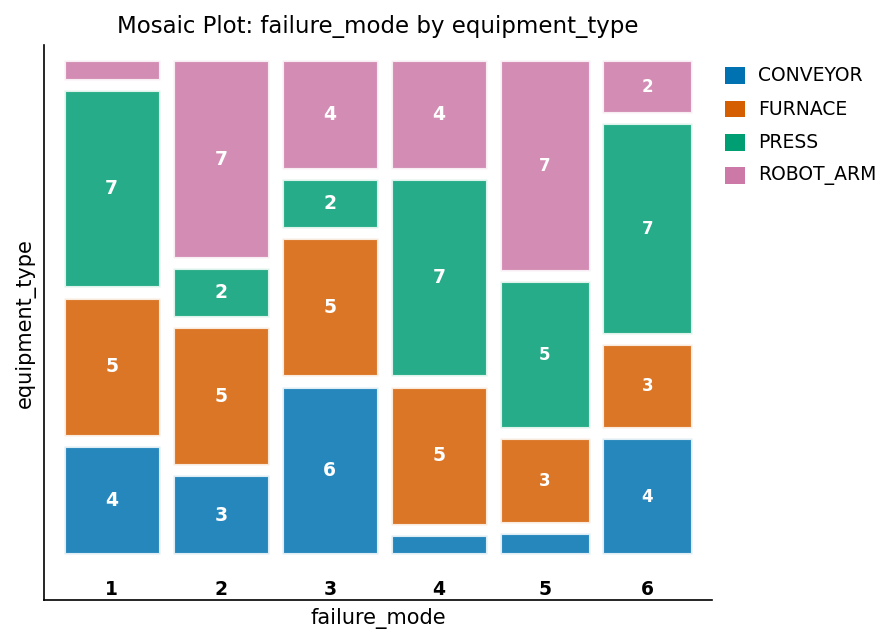

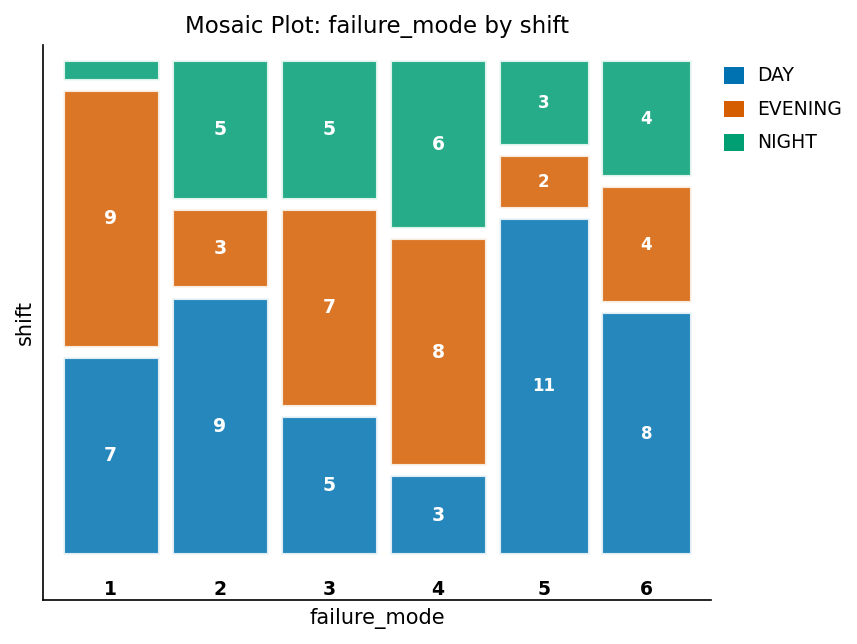

In [8]:
/* --------------------------------------------------------
   Cross-tabulate failure modes by equipment type
   and shift to identify systematic patterns
   -------------------------------------------------------- */
PROCEDUR FREKVENSER data=work.failures_classified;
    TABLES failure_mode * equipment_type / chisq nocol nopercent;
    TABLES failure_mode * shift / chisq nocol nopercent;
    TITEL 'Failure Mode Distribution by Equipment and Shift';
KÖR;

---

### Tolkning

Klustring med komplett länkning av de 100 standardiserade felhändelserna ger **sex felmoder** av nästan lika storlek (n = 17, 17, 17, 17, 16, 16). Moderna särskiljs av sina symtomsignaturer i `PROC MEANS`-profilen ovan:

- **Mod 6** bär den tyngsta signaturen av mekanisk belastning: högsta medelvibration (4,97), högsta tryckfall (7,51) och högsta strömspik (1,61) — men den **lägsta** momentvariansen (1,28).
- **Mod 3** är den termiska moden: högsta temperaturdelta (16,3 C) med det lägsta medelljudet (73,0 dB).
- **Mod 2** har den **längsta stilleståndstiden** med bred marginal (medel 85,6 minuter mot 31–52 för de övriga moderna) och förhöjd momentvarians (3,57), vilket pekar på händelser som är dyrare att återhämta sig från.
- **Mod 4** är den mildaste: lägsta stilleståndstid (31,4 minuter) och tryckfall och oljepartikelantal under genomsnittet.
- **Mod 1 och 5** är grupper med blandade symtom utan någon enskild dominerande drivkraft.

`PROC FREQ`-korstabuleringarna testar om dessa moder koncentreras till särskild utrustning eller särskilda skift. Vid denna stickprovsstorlek gör de **inte** det: mod mot utrustningstyp ger chi-två = 20,48 (15 fg, p = 0,154, Cramérs V = 0,26) och mod mot skift ger chi-två = 17,13 (10 fg, p = 0,072, Cramérs V = 0,29) — båda över tröskeln 0,05, och över 80 % av cellerna har förväntade antal under 5, så chi-två är i sig endast antydande. De synliga tendenserna (Mod 6 lutar mot PRESS, Mod 5 mot dagskiftet) är beskrivande snarare än signifikanta här.

**Slutsats:** komplett länkning på standardiserade symtomprofiler ger en tolkbar taxonomi med sex moder kopplad till temperatur, tryck och stilleståndstid. För att bekräfta om moder kartläggs mot specifik utrustning eller specifika skift — den handlingsbara grundorsaksfrågan — behöver analysen hela händelsehistoriken snarare än detta urval på 100 händelser, där korstabuleringarna förblir underdimensionerade i styrka.

---

In [9]:
/* --------------------------------------------------------
   Export failure classifications for CMMS integration
   -------------------------------------------------------- */
PROCEDUR EXPORTERA data=work.failures_classified
    OUTFILE='failure_mode_classifications.csv'
    DBMS=csv REPLACE;
KÖR;

NOTE: PROC EXPORT data=work.failures_classified outfile=failure_mode_classifications.csv

NOTE: Exported 100 rows to failure_mode_classifications.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Konfidentiellt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drivs av <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>